In [1]:
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os
from torchvision import transforms
from transformers import AutoModel, AutoTokenizer
import torchvision.models as models

In [ ]:
model_name = "google-bert/bert-base-uncased"

In [3]:
class channelDataset(Dataset):
    def __init__(self, metadata_path = "processed/metadata.csv", split="train", image_size = 224, max_text_length = 512):
        super().__init__()
        self.split = split
        self.data_dir = os.path.dirname(metadata_path)
        self.metadata = pd.read_csv(metadata_path)
        self.image_size = image_size
        self.labels = sorted(self.metadata["label"].unique())
        self.label_to_idx = {label: i for i, label in enumerate(self.labels)}
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        self.max_text_length = max_text_length
        # print(self.metadata.iloc[0])

    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, index):
        row = self.metadata.iloc[index]

        text_path = os.path.join(self.data_dir, row["text_file"])
        with open(text_path, 'r', encoding='utf-8') as f:
            text = f.read().strip()
        text_tokens = self._tokenize_text(text)

        has_image = False
        if row["has_image"]:
            has_image = True
            img_path = os.path.join(self.data_dir, row["image_file"])
            image = Image.open(img_path).convert("RGB")
            image = self._transform_image(image)
        else:
            image = torch.ones(3, self.image_size, self.image_size)
    
        label_idx = self.label_to_idx[row["label"]]
        label = torch.tensor(label_idx, dtype=torch.long)

        return {
            'input_ids': text_tokens['input_ids'],
            'attention_mask': text_tokens['attention_mask'],
            'image': image,
            'label': label,
            'has_image': has_image
        }

    def _transform_image(self, image):
        if self.split == "train":
            transform =  transforms.Compose([
                transforms.Resize((self.image_size, self.image_size)),
                transforms.RandomHorizontalFlip(0.3),
                transforms.RandomRotation(10),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                   std=[0.229, 0.224, 0.225])
            ])
        else:
            transform = transforms.Compose([
                transforms.Resize((self.image_size, self.image_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                   std=[0.229, 0.224, 0.225])
            ])
        return transform(image)

    def _tokenize_text(self, text):
        tokens = self.tokenizer(
            text,
            max_length = self.max_text_length,
            padding='max_length', 
            truncation=True,
            return_tensors='pt'
        )
        return{
            'input_ids': tokens['input_ids'].squeeze(0),  
            'attention_mask': tokens['attention_mask'].squeeze(0)
        }


In [4]:
class MultiModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.text_model = AutoModel.from_pretrained(model_name) #trust_remote_code=True
        self.image_model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)#, pretrained=True
        self.image_model.fc = nn.Identity()

        total_bert_layers = len(self.text_model.encoder.layer)
        for param in self.text_model.parameters():
            param.requires_grad = False
        bert_unfreez = 1
        for i in range(total_bert_layers - bert_unfreez, total_bert_layers):
            for param in self.text_model.encoder.layer[i].parameters():
                param.requires_grad = True
        for param in self.text_model.pooler.parameters():
            param.requires_grad = True

        for param in self.image_model.parameters():
            param.requires_grad = False
        # for param in self.image_model.layer3.parameters():
        #     param.requires_grad = True
        for param in self.image_model.layer4.parameters():
            param.requires_grad = True

        self.num_classes = num_classes
        text_output = self.text_model.config.hidden_size
        image_output = 512
        comb_out = text_output + image_output
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(comb_out, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, self.num_classes)
        )
    
    def forward(self, input_ids, attention_mask, image):
        text_features = self.text_model(
            input_ids = input_ids, 
            attention_mask = attention_mask
        ).pooler_output

        image_features = self.image_model(image)

        comb = torch.cat([text_features, image_features], dim=1)

        return self.classifier(comb)

In [26]:
import torch.optim as optim
from tqdm import tqdm

def train(model, 
    train_dataloader, val_dataloader, criterion = nn.CrossEntropyLoss(), num_epochs=10, 
    device = 'cuda' if torch.cuda.is_available() else 'cpu', lr = 1e-3):
    model = model.to(device)
    criterion = criterion
    optimizer = optim.AdamW(model.parameters(), lr = lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for batch in tqdm(train_dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            image = batch['image'].to(device)
            label = batch['label'].to(device)

            optimizer.zero_grad()
            output = model(input_ids, attention_mask, image)
            loss = criterion(output, label)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = output.max(1)
            train_total += label.size(0)
            train_correct += predicted.eq(label).sum().item()
            
        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_acc = 100. * train_correct / train_total

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch in tqdm(val_dataloader):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                images = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(input_ids, attention_mask, images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        avg_val_loss = val_loss / len(val_dataloader)
        avg_val_acc = 100. * val_correct / val_total
        scheduler.step(avg_val_acc)
        # scheduler.step()

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)

        print(f"Epoch: {epoch+1}:")
        print(f"   Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
        print(f"   Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%")

        if avg_val_acc == max(history['val_acc']):
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            }, 'best_model.pth')
    
    torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            }, 'model.pth')
        
    return history

In [22]:
from torch.utils.data import random_split

ds = channelDataset("/kaggle/input/misis-posts-classification/processed/metadata.csv")
train_size = int(len(ds)*0.8)
val_size = len(ds) - train_size
train_ds, val_ds = random_split(
    ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataloader = DataLoader(train_ds, batch_size = 16, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)

model = MultiModel(len(ds.labels))

history = train(
    model, 
    train_dataloader, 
    val_dataloader,
    num_epochs = 25,
    lr = 1e-4
)

100%|██████████| 13/13 [00:07<00:00,  1.74it/s]


Epoch: 1:
   Train Loss: 1.7131 | Train Acc: 35.70%
   Val Loss:   1.3519 | Val Acc:   54.95%


100%|██████████| 13/13 [00:07<00:00,  1.82it/s]


Epoch: 2:
   Train Loss: 1.2540 | Train Acc: 56.34%
   Val Loss:   1.0824 | Val Acc:   62.87%


100%|██████████| 13/13 [00:07<00:00,  1.81it/s]


...

Epoch: 23:
   Train Loss: 0.2003 | Train Acc: 94.40%
   Val Loss:   0.7472 | Val Acc:   78.22%


100%|██████████| 13/13 [00:07<00:00,  1.82it/s]


Epoch: 24:
   Train Loss: 0.1867 | Train Acc: 96.27%
   Val Loss:   0.7544 | Val Acc:   76.73%


100%|██████████| 13/13 [00:07<00:00,  1.82it/s]

Epoch: 25:
   Train Loss: 0.1964 | Train Acc: 94.65%
   Val Loss:   0.7829 | Val Acc:   77.72%


In [ ]:
history = train(
    model, 
    train_dataloader, 
    val_dataloader,
    num_epochs = 25,
    lr = 1e-4
)

100%|██████████| 13/13 [00:06<00:00,  1.87it/s]


Epoch: 1:
   Train Loss: 1.6969 | Train Acc: 35.57%
   Val Loss:   1.4296 | Val Acc:   47.52%


100%|██████████| 13/13 [00:06<00:00,  1.93it/s]


Epoch: 2:
   Train Loss: 1.3209 | Train Acc: 53.11%
   Val Loss:   1.1189 | Val Acc:   66.34%


100%|██████████| 13/13 [00:06<00:00,  1.88it/s]


...

Epoch: 23:
   Train Loss: 0.1633 | Train Acc: 97.01%
   Val Loss:   0.7744 | Val Acc:   77.72%


100%|██████████| 13/13 [00:06<00:00,  1.91it/s]


Epoch: 24:
   Train Loss: 0.1644 | Train Acc: 95.40%
   Val Loss:   0.7757 | Val Acc:   76.73%


100%|██████████| 13/13 [00:06<00:00,  1.90it/s]


Epoch: 25:
   Train Loss: 0.1708 | Train Acc: 96.02%
   Val Loss:   0.7259 | Val Acc:   79.70%


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_loss(history):
    plt.figure(figsize=(10, 6))

    epochs = range(1, len(history['train_loss'])+1)

    plt.plot(epochs, history['train_loss'], 'b-', label='train loss')
    plt.plot(epochs, history['val_loss'], 'r-', label="val loss")
    plt.title("train/val loss")
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.legend()
    plt.grid(visible=True)
    plt.show()

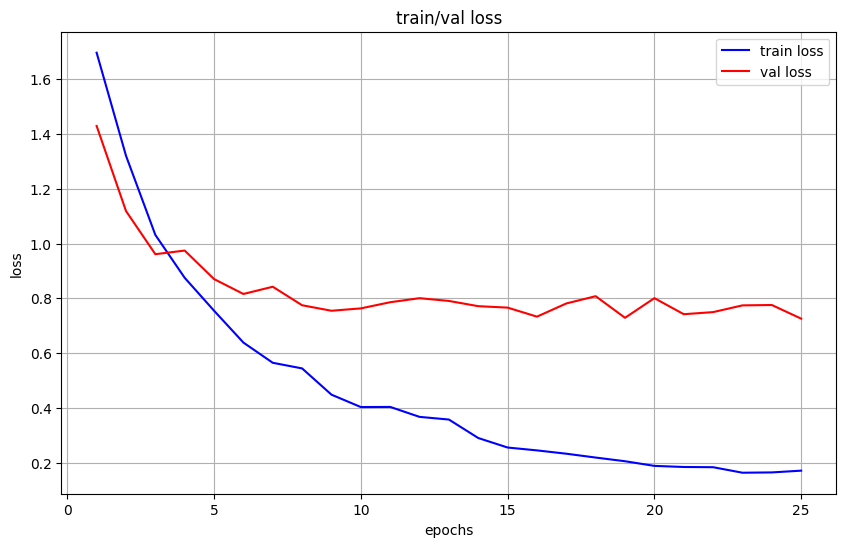

In [14]:
plot_loss(history)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef

def evaluate_model(model, val_dataloader):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.eval()
    all_predictions = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            image = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, image)
            probs = outputs.softmax(dim=1)
            val, predict = probs.max(dim=1)
            
            all_predictions.extend(predict.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return all_labels, all_predictions, all_probs

In [20]:
def calc_metrics(y_true, y_pred, y_probs, labels):
    accuracy = accuracy_score(y_true, y_pred)
    
    report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title("Confusion Matrix")
    plt.ylabel('true')
    plt.xlabel('predict')
    plt.tight_layout()
    plt.show()

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    micro_f1 = f1_score(y_true, y_pred, average='micro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    # kappa = cohen_kappa_score(y_true, y_pred)
    # # 7. Matthews Correlation Coefficient (MCC)
    # mcc = matthews_corrcoef(y_true, y_pred)

    return {
        'accuracy': accuracy,
        'report': report,
        'confusion_matrix': cm,
        'macro_f1': macro_f1,
        'micro_f1': micro_f1,
        'weighted_f1': weighted_f1
    }

In [30]:
checkpoint = torch.load("/kaggle/input/model-v-0/best_model.pth")
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

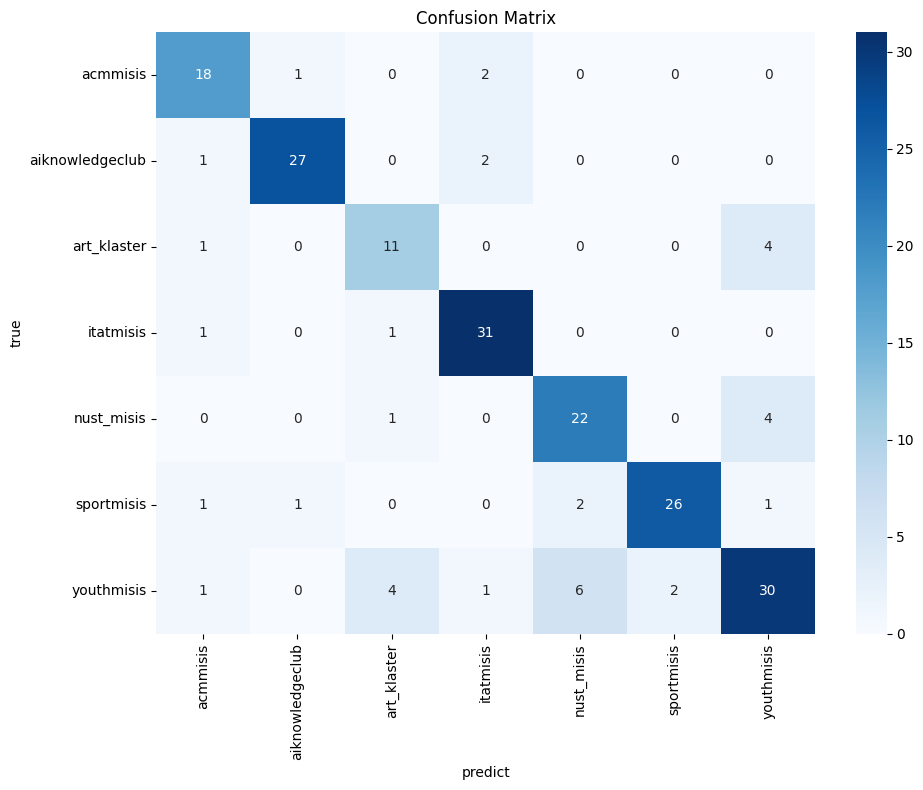

Accuracy: 0.8168
Macro F1: 0.8107
Weighted F1: 0.8165

Classification Report:
                 precision    recall  f1-score   support

       acmmisis       0.78      0.86      0.82        21
aiknowledgeclub       0.93      0.90      0.92        30
    art_klaster       0.65      0.69      0.67        16
      itatmisis       0.86      0.94      0.90        33
     nust_misis       0.73      0.81      0.77        27
     sportmisis       0.93      0.84      0.88        31
     youthmisis       0.77      0.68      0.72        44

       accuracy                           0.82       202
      macro avg       0.81      0.82      0.81       202
   weighted avg       0.82      0.82      0.82       202



In [31]:
y_true, y_pred, y_probs = evaluate_model(model, val_dataloader)

metrics = calc_metrics(y_true, y_pred, y_probs, ds.labels)

print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Macro F1: {metrics['macro_f1']:.4f}")
print(f"Weighted F1: {metrics['weighted_f1']:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=ds.labels))

In [25]:
import os
import json
import subprocess
from pathlib import Path

KAGGLE_JSON_PATH = '/kaggle/input/kaggle/kaggle.json'  

!mkdir -p /root/.kaggle
!cp {KAGGLE_JSON_PATH} /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# torch.save(model.state_dict(), '/kaggle/working/final_model.pth')

dataset_metadata = {
    "title": "MISIS-Posts-Classification-Model",
    "id": "cvbnqq/MISIS-Posts-Classification-Model",  
    "licenses": [{"name": "CC0-1.0"}],
    "description": "Trained model weights from my project"
}

with open('/kaggle/working/dataset-metadata.json', 'w') as f:
    json.dump(dataset_metadata, f)

result = subprocess.run([
    'kaggle', 'datasets', 'create',
    '-p', '/kaggle/working',
    '--dir-mode', 'zip'
], capture_output=True, text=True)

print("Output:", result.stdout)
print("Errors:", result.stderr)

Output: Starting upload for file best_model.pth
Upload successful: best_model.pth (662MB)
Starting upload for file .virtual_documents.zip
Upload successful: .virtual_documents.zip (22B)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/cvbnqq/MISIS-Posts-Classification-Model

Errors: 
  0%|          | 0.00/662M [00:00<?, ?B/s]
  0%|          | 2.91M/662M [00:00<00:22, 30.5MB/s]
  5%|▍         | 30.3M/662M [00:00<00:05, 123MB/s] 
  7%|▋         | 46.9M/662M [00:00<00:04, 142MB/s]
  9%|▉         | 60.0M/662M [00:00<00:04, 136MB/s]
 11%|█         | 74.3M/662M [00:00<00:04, 140MB/s]
 14%|█▍        | 92.2M/662M [00:00<00:04, 145MB/s]
 16%|█▌        | 106M/662M [00:00<00:04, 144MB/s] 
 18%|█▊        | 120M/662M [00:00<00:04, 133MB/s]
 20%|██        | 135M/662M [00:01<00:04, 134MB/s]
 23%|██▎       | 155M/662M [00:01<00:03, 149MB/s]
 26%|██▌       | 169M/662M [00:01<00:03, 149MB/s]
 28%|██▊       | 184M/662M [00:01<00:03, 146MB/s]
 30%|██▉       |

In [ ]:
!jupyter nbconvert --to script --no-prompt train.ipynb --output train

[NbConvertApp] Converting notebook train.ipynb to script
[NbConvertApp] Writing 13375 bytes to train.py.py
